<a href="https://colab.research.google.com/github/jainamm-gala/ML_Mini_Project_SEM6/blob/main/ML_Mini_Project_SEM6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv')

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [26]:
# Drop unnecessary column
df = df.drop('loan_id', axis=1)

# Strip spaces in column names (important)
df.columns = df.columns.str.strip()

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [27]:
# Encoding
df['education'] = df['education'].str.strip().map({'Graduate':1, 'Not Graduate':0})
df['self_employed'] = df['self_employed'].str.strip().map({'Yes':1, 'No':0})
df['loan_status'] = df['loan_status'].str.strip().map({'Approved':1, 'Rejected':0})

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [28]:
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [29]:
#no missing values founded here so we will not use this (df.fillna(df.mean(numeric_only=True), inplace=True)) here

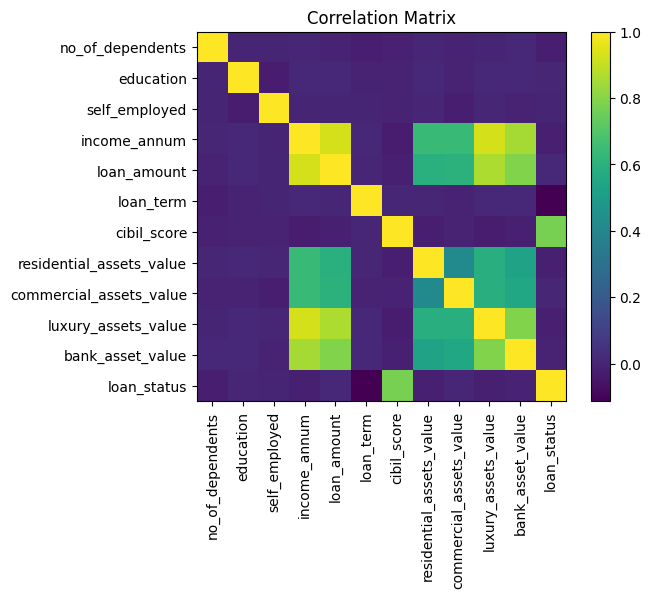

In [30]:
corr = df.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [31]:
selected_features = ['cibil_score', 'loan_term', 'loan_amount', 'income_annum']
X = df[selected_features]
y = df['loan_status']

In [32]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
#Logistic Regression-Algo_1
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [34]:
#Decision Tree-Algo_2
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [35]:
#Support Vector Machines(SVM)-ALgo_3
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [36]:
#Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("\n")

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("SVM", y_test, y_pred_svm)

--- Logistic Regression ---
Accuracy: 0.7927400468384075
Confusion Matrix:
 [[190 128]
 [ 49 487]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.60      0.68       318
           1       0.79      0.91      0.85       536

    accuracy                           0.79       854
   macro avg       0.79      0.75      0.76       854
weighted avg       0.79      0.79      0.79       854



--- Decision Tree ---
Accuracy: 0.9800936768149883
Confusion Matrix:
 [[310   8]
 [  9 527]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       318
           1       0.99      0.98      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



--- SVM ---
Accuracy: 0.6276346604215457
Confusion Matrix:
 [[  0 318]
 [  0 536]]
Classification Repo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


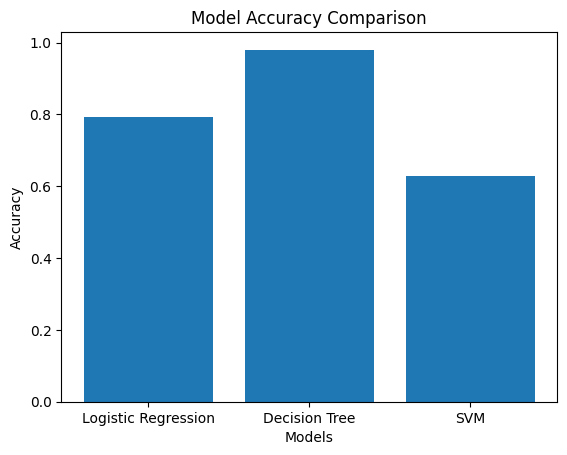

In [37]:
#Now we are giving the comparison between the accuracies
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_svm = accuracy_score(y_test, y_pred_svm)

models = ['Logistic Regression', 'Decision Tree', 'SVM']
accuracy = [acc_lr, acc_dt, acc_svm]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

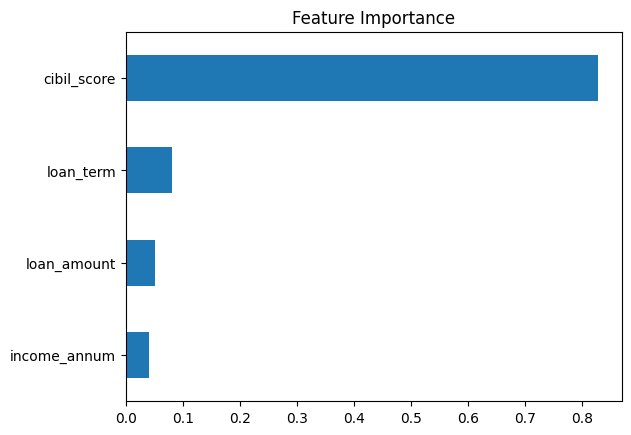

In [38]:
#declaring/assuming the important feature
import pandas as pd

importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

/tmp/ipykernel_41805/1116308731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='cibil_score', data=df, palette='viridis')


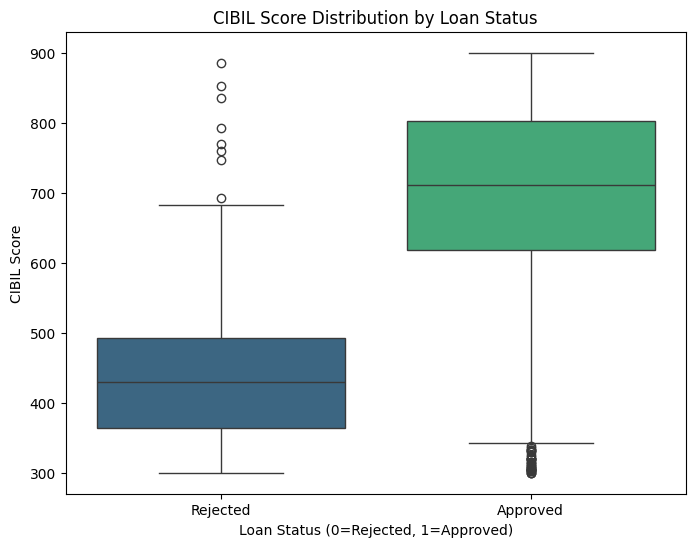

In [39]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_status', y='cibil_score', data=df, palette='viridis')
plt.title('CIBIL Score Distribution by Loan Status')
plt.xlabel('Loan Status (0=Rejected, 1=Approved)')
plt.ylabel('CIBIL Score')
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.show()

In [40]:
sample = X.iloc[0].values.reshape(1, -1)

sample_df = pd.DataFrame(sample, columns=X.columns)

prediction = lr.predict(sample_df)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


### Predict Loan Approval for a New Applicant

Below, you can input the details for a new applicant. Ensure you provide values for all the features that the model was trained on. Remember that `education` and `self_employed` are encoded as 0 or 1 (0 for 'Not Graduate'/ 'No' and 1 for 'Graduate' / 'Yes').

In [41]:
new_applicant_data = {
    'cibil_score': 750,
    'loan_term': 15,
    'loan_amount': 20000000,
    'income_annum': 7000000
}

# Convert to DataFrame
new_applicant_df = pd.DataFrame([new_applicant_data], columns=X.columns)

# Predict using the Decision Tree model (dt)
# dt.predict_proba returns the probability of each class [probability_rejected, probability_approved]
prediction_proba = dt.predict_proba(new_applicant_df)
predicted_status = dt.predict(new_applicant_df)[0]

print(f"Applicant Data:\n{new_applicant_df.to_string(index=False)}")
print(f"\nProbability of Loan Rejection: {prediction_proba[0][0]*100:.2f}%")
print(f"Probability of Loan Approval: {prediction_proba[0][1]*100:.2f}%")

if predicted_status == 1:
    print("Based on the model, the loan is **Approved**.")
else:
    print("Based on the model, the loan is **Rejected**.")

Applicant Data:
 cibil_score  loan_term  loan_amount  income_annum
         750         15     20000000       7000000

Probability of Loan Rejection: 0.00%
Probability of Loan Approval: 100.00%
Based on the model, the loan is **Approved**.


### Interactive Loan Approval Predictor

Use the sliders and input fields below to enter details for a new applicant and see the loan approval prediction based on our Decision Tree model.

In [42]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Create input widgets for the selected features
cibil_score_widget = widgets.IntSlider(
    value=700,
    min=300,
    max=900,
    step=1,
    description='CIBIL Score:',
    continuous_update=False
)

loan_term_widget = widgets.IntSlider(
    value=10,
    min=2,
    max=20,
    step=1,
    description='Loan Term (Years):',
    continuous_update=False
)

loan_amount_widget = widgets.IntText(
    value=15000000,
    description='Loan Amount:',
    disabled=False
)

income_annum_widget = widgets.IntText(
    value=5000000,
    description='Annual Income:',
    disabled=False
)

output_widget = widgets.Output()

In [ ]:
def predict_loan_status(cibil_score, loan_term, loan_amount, income_annum):
    with output_widget:
        output_widget.clear_output()
        new_applicant_data = {
            'cibil_score': cibil_score,
            'loan_term': loan_term,
            'loan_amount': loan_amount,
            'income_annum': income_annum
        }

        new_applicant_df = pd.DataFrame([new_applicant_data], columns=X.columns)

        prediction_proba = dt.predict_proba(new_applicant_df)
        predicted_status = dt.predict(new_applicant_df)[0]

        display(HTML(f"<b>Applicant Data:</b><br>{new_applicant_df.to_string(index=False).replace(' ', '&nbsp;').replace('\n', '<br>')}"))
        print(f"\nProbability of Loan Rejection: {prediction_proba[0][0]*100:.2f}%")
        print(f"Probability of Loan Approval: {prediction_proba[0][1]*100:.2f}%")

        if predicted_status == 1:
            display(HTML("<br><span style='color:green;'><b>Based on the model, the loan is Approved.</b></span>"))
        else:
            display(HTML("<br><span style='color:red;'><b>Based on the model, the loan is Rejected.</b></span>"))

# Link widgets to the prediction function
widgets.interactive_output(
    predict_loan_status,
    {
        'cibil_score': cibil_score_widget,
        'loan_term': loan_term_widget,
        'loan_amount': loan_amount_widget,
        'income_annum': income_annum_widget
    }
)

# Display the widgets and output area
display(
    widgets.VBox([
        cibil_score_widget,
        loan_term_widget,
        loan_amount_widget,
        income_annum_widget,
        output_widget
    ])
)

In [44]:
#getting the probabilities either 0% or 100% because the decision tree has learned very distinct values ,either approval and rejection.